In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### Intro

In [78]:
def f(x):
    return 3*x**2 - 4*x + 5

In [79]:
print(f(3))

20


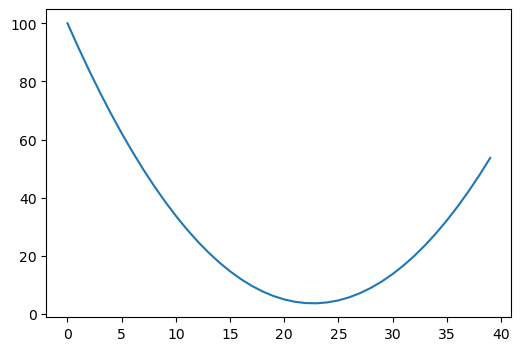

In [80]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.figure(figsize = (6,4))
plt.plot(ys)
plt.show()

In [81]:
h = 0.00000001
x = 3

d1 = (f(x+h) - f(x))/h
print(d1)

x = -3
d2 = (f(x+h) - f(x))/h
print(d2)

x = 2/3
d3 = (f(x+h) - f(x))/h
print(d3)

14.00000009255109
-22.00000039920269
0.0


In [82]:
h = 0.0001

a = 2
b = -3
c = 10

d1 = a*b + c
#a += h
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4
d2 4.0001
slope 0.9999999999976694


## The Main Code For the Class Value

In [83]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda : None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):   #represent the object by the defined format in the return statement 
        return f'value(data = {self.data})'
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # added to support addition by an integer or float
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad  #   = 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward 
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # added to support multiplication by an integer or float
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += out.grad * other.data  # = out.grad * other.data
            other.grad += out.grad * self.data  # = out.grad * self.data
            
        out._backward = _backward 
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')
        
        def _backward():
            self.grad += other * (self.data**(other-1)) * out.grad
            
        out._backward = _backward  
        
        return out
    
    def __neg__(self):  # -self # - __neg__: Implements unary negation (-self).
        
        return self * -1
    
    def __sub__(self, other):   # self - other
        return self + (-other) # - __sub__: Implements subtraction (self - other) as self + (-other).
    
    def __truediv__(self, other): # self/other
        return self*other**-1  # __truediv__: Implements division (self / other) as self * other**-1.
    
    def __rmul__(self, other): # other*self => to support if integer/float multiplies by Value object
        return self * other   #__rmul__: Supports reverse multiplication (e.g., 3 * self) by calling self * 3.
    
    def __radd__(self, other): # other+self => to support if integer/float add by Value object
        return self + other  #  __radd__: Supports reverse addition (e.g., 3 + self) by calling self + 3.    
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad 
            
        out._backward = _backward    
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, _children=(self,), _op = 'tanh')
        
        def _backward():
            self.grad += out.grad * (1-t**2)  # = out.grad * (1-t**2)
            
        out._backward = _backward 
        
        return out
    
    def backward(self):
        topo = []
        seen = set()
        def build_topo(v):
            if not v in seen:
                seen.add(v)
                for node in v._prev:
                    build_topo(node)
                topo.append(v)
        
        build_topo(self)
        self.grad = 1.0
        
        for node in reversed(topo): # reversed is used to start from the last node backward.
            node._backward()
                
        


### Practice on Mathematical Expressions

In [84]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b;   e.label = 'e'
d = e + c;  d.label = 'd' 
f = Value(-2.0,label = 'f')
L = f*d ; L.label = 'L'
L

value(data = -8.0)

In [85]:
print('a children: =>', a._prev)
print('a operation: =>', a._op)
print('a: =>', a)
print('grad: =>', a.grad)

a children: => set()
a operation: => 
a: => value(data = 2.0)
grad: => 0.0


In [86]:
print('b children: =>', b._prev)
print('b operation: =>', b._op)
print('b: =>', b)
print('grad: =>', b.grad)

b children: => set()
b operation: => 
b: => value(data = -3.0)
grad: => 0.0


In [87]:
print('e children: =>', e._prev)
print('e operation: =>', e._op)
print('e: =>', e)
print('grad: =>', e.grad)

e children: => {value(data = -3.0), value(data = 2.0)}
e operation: => *
e: => value(data = -6.0)
grad: => 0.0


In [88]:
print('c children: =>', c._prev)
print('c operation: =>', c._op)
print('c: =>', c)
print('grad: =>', c.grad)

c children: => set()
c operation: => 
c: => value(data = 10.0)
grad: => 0.0


In [89]:
print('d:=>', d)
print('d children: =>', d._prev)
print('d operation: =>', d._op)
print('grad: =>', d.grad)

d:=> value(data = 4.0)
d children: => {value(data = 10.0), value(data = -6.0)}
d operation: => +
grad: => 0.0


In [90]:
print('f:=>', f)
print('f children: =>', f._prev)
print('f operation: =>', f._op)
print('grad: =>', f.grad)

f:=> value(data = -2.0)
f children: => set()
f operation: => 
grad: => 0.0


In [91]:
print('L:=>', L)
print('L children: =>', L._prev)
print('L operation: =>', L._op)
print('grad: =>', L.grad)

L:=> value(data = -8.0)
L children: => {value(data = -2.0), value(data = 4.0)}
L operation: => *
grad: => 0.0


In [92]:
L.grad = 1.0
f.grad = 4.0 #  L = f*D ==> dL/df = d
d.grad = -2.0 #  L = f*D ==> dL/dd = f

print('dL/dL: =>', L.grad)
print('dL/df: =>', f.grad)
print('dL/dd: =>', d.grad)

dL/dL: => 1.0
dL/df: => 4.0
dL/dd: => -2.0


In [93]:
# d = e+c
# dL/dc = dL/dd * dd/dc   -- dd/dc = 1  ==> dL/dc = dL/dd
# dL/de = dL/dd * dd/de   -- dd/de = 1  ==> dL/de = dL/dd
c.grad = -2.0
e.grad = -2.0    # sum operator just routs the gradients through mathematical expressions. 
#meaning sum operator just distributes gragiants to childeren(previous) nodes 
print('dL/dc: =>', c.grad)
print('dL/de: =>', e.grad)

dL/dc: => -2.0
dL/de: => -2.0


In [94]:
# e = a*b
# dL/da = dL/de * de/da --- de/da = b ==> dL/da = dL/de * b
a.grad = -2.0*-3.0

# dL/db = dL/de * de/db --- de/db = a ==> dL/db = dL/de * a
b.grad = -2.0*2.0

print('dL/da: =>', a.grad)
print('dL/db: =>', b.grad)

dL/da: => 6.0
dL/db: => -4.0


In [95]:
# Backpropagation is the recursive application of chain rule.
# Backpropagation is an algorithm of evaluating gradiants of parameters with respect to a Loss function

In [96]:
from graphviz import Digraph

In [97]:
# to visiualize the expressions
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

### Practice on a preceptron - Manual Practice

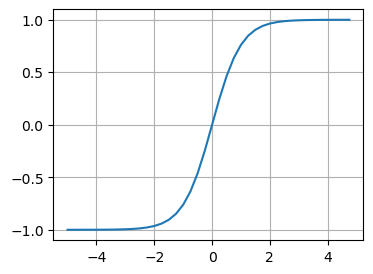

In [98]:
plt.figure(figsize=(4,3)) ; plt.plot(np.arange(-5, 5, 0.25), np.tanh(np.arange(-5, 5, 0.25))); plt.grid(); plt.show()

In [99]:
# Inputs
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# Weights
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# Bias
b = Value(6.8813735870195432,label = 'b')
# w1x1 + w2x2 + b
w1x1 = w1*x1 ; w1x1.label = 'w1x1'
w2x2 = w2*x2 ; w2x2.label = 'w2x2'
w1x1w2x2 = w1x1 + w2x2 ; w1x1w2x2.label = 'w1x1w2x2'
n = w1x1w2x2 + b ; n.label= 'n'

o = n.tanh(); o.label = 'o'
o

value(data = 0.7071067811865476)

In [100]:
# Just to practice the graph tracing function
def trace_graph(root):
    seen, oop_dct, = set(), dict()
    def build(v):
        if v.label not in seen:
            seen.add(v.label)
            for child in v._prev:
                build(child)
            oop_dct[v.label] = v.data # it should be here, because we want to add the node after visiting its children   
    build(root)
    return oop_dct
oop_dct = trace_graph(o)
oop_dct

{'x2': 0.0,
 'w2': 1.0,
 'w2x2': 0.0,
 'w1': -3.0,
 'x1': 2.0,
 'w1x1': -6.0,
 'w1x1w2x2': -6.0,
 'b': 6.881373587019543,
 'n': 0.8813735870195432,
 'o': 0.7071067811865476}

In [101]:
# Just to practice the graph tracing function
seen, oop, oop_values = [], [], []
def build(v):    
    if not v.label in seen:
        seen.append(v.label) 
        for child in v._prev:
            build(child)
        oop.append(v.label)
        oop_values.append(v.data) #it should be here, because we want to add the node after visiting its children       
    return oop, oop_values
oop, oop_values = build(o)
print(oop)
print(oop_values)        
        


['x2', 'w2', 'w2x2', 'w1', 'x1', 'w1x1', 'w1x1w2x2', 'b', 'n', 'o']
[0.0, 1.0, 0.0, -3.0, 2.0, -6.0, -6.0, 6.881373587019543, 0.8813735870195432, 0.7071067811865476]


In [102]:
#draw_dot(n)

In [103]:
# w1x1 = w1*x1
#do/dw1 = do/dw1x1 * dw1x1/dw1 = w1x1.grad * x1.data
w1.grad = w1x1.grad * x1.data
#do/dx1 = do/dw1x1 * dw1x1/dx1 = w1x1.grad * w1.data
x1.grad = w1x1.grad * w1.data

w1.grad, x1.grad

(0.0, -0.0)

In [104]:
# w2x2 = w2*x2
#do/dw2 = do/dw2x2 * dw2x2/dw2 = w2x2.grad * x2.data
w2.grad = w2x2.grad * x2.data
#do/dx2 = do/dw2x2 * dw2x2/dx2 = w2x2.grad * w2.data
x2.grad = w2x2.grad * w2.data

w2.grad, x2.grad

(0.0, 0.0)

In [105]:
# w1x1w2x2 = w1x1 + w2x2 ==> gradient of w1x1w2x2 is going to be distributed to w1x1 and w2x2
w1x1.grad = w1x1w2x2.grad
w2x2.grad = w1x1w2x2.grad
w1x1.grad, w2x2.grad

(0.0, 0.0)

In [106]:
# n = w1x1w2x2 + b ==> gradient of n is going to be distributed to w1x1w2x2 and b
w1x1w2x2.grad = n.grad
b.grad = n.grad
w1x1w2x2.grad, b.grad

(0.0, 0.0)

In [107]:
# do/dn; o = tanh(n)  ==> do/dn = 1 - tanh(n)**2 = 1- o**2
n.grad = 1- (o.data)**2
n.grad

0.4999999999999999

In [108]:
o.grad = 1 # do/do = 1

### Practice on a preceptron - After implementing relevant codes in the Value Class. Transition from Mannual to Automatic

##### Semi Automatic calculation

In [109]:
# Inputs
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# Weights
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# Bias
b = Value(6.8813735870195432,label = 'b')
# w1x1 + w2x2 + b
w1x1 = w1*x1 ; w1x1.label = 'w1x1'
w2x2 = w2*x2 ; w2x2.label = 'w2x2'
w1x1w2x2 = w1x1 + w2x2 ; w1x1w2x2.label = 'w1x1w2x2'
n = w1x1w2x2 + b ; n.label= 'n'

o = n.tanh(); o.label = 'o'
o

value(data = 0.7071067811865476)

In [110]:
o.grad = 1.0 # have to set o.grad = 0.1 because do/do is 1.
o._backward() # this command calls backward function that had been stored in _backward variable of this node in forward path.
# we assigned backward function to o._backward in forward path buy running it with out.grad == 0 wich results in having 
# gradient of zero for n. But after setting o.grad = 1.0 and calling backward function again on o, the gradient of n is recalculated
n.grad

0.4999999999999999

In [111]:
n._backward()
w1x1w2x2.grad, b.grad

(0.4999999999999999, 0.4999999999999999)

In [112]:
w1x1w2x2._backward()
w1x1.grad, w2x2.grad

(0.4999999999999999, 0.4999999999999999)

In [113]:
w1x1._backward()
w1.grad, x1.grad 

(0.9999999999999998, -1.4999999999999996)

In [114]:
w2x2._backward()
w2.grad, x2.grad 

(0.0, 0.4999999999999999)

##### Automatic Calculation

In [115]:
# Inputs
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# Weights
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# Bias
b = Value(6.8813735870195432,label = 'b')
# w1x1 + w2x2 + b
w1x1 = w1*x1 ; w1x1.label = 'w1x1'
w2x2 = w2*x2 ; w2x2.label = 'w2x2'
w1x1w2x2 = w1x1 + w2x2 ; w1x1w2x2.label = 'w1x1w2x2'
n = w1x1w2x2 + b ; n.label= 'n'

o = n.tanh(); o.label = 'o'
o

value(data = 0.7071067811865476)

In [116]:
topo = []
visited = set()
def build_topo(v):
    if not v in visited:
        visited.add(v)
        for node in v._prev:
            build_topo(node)    
    topo.append(v)
    return topo
build_topo(o)
topo

[value(data = 6.881373587019543),
 value(data = 0.0),
 value(data = 1.0),
 value(data = 0.0),
 value(data = -3.0),
 value(data = 2.0),
 value(data = -6.0),
 value(data = -6.0),
 value(data = 0.8813735870195432),
 value(data = 0.7071067811865476)]

In [117]:
o.grad = 1.0
for node in reversed(topo):
    node._backward()
    print(node.grad)

1.0
0.4999999999999999
0.4999999999999999
0.4999999999999999
-1.4999999999999996
0.9999999999999998
0.4999999999999999
0.0
0.4999999999999999
0.4999999999999999


##### After implementing topological function in the class

In [38]:
# Inputs
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# Weights
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# Bias
b = Value(6.8813735870195432,label = 'b')
# w1x1 + w2x2 + b
w1x1 = w1*x1 ; w1x1.label = 'w1x1'
w2x2 = w2*x2 ; w2x2.label = 'w2x2'
w1x1w2x2 = w1x1 + w2x2 ; w1x1w2x2.label = 'w1x1w2x2'
n = w1x1w2x2 + b ; n.label= 'n'

o = n.tanh(); o.label = 'o'
o

value(data = 0.7071067811865476)

In [39]:
o.backward()
print('o: ', o.grad)
print('n: ', n.grad)
print('w1x1w2x2: ', w1x1w2x2.grad)
print('b: ', b.grad)
print('w1x1: ', w1x1.grad)
print('w2x2: ', w2x2.grad)
print('w1: ', w1.grad)
print('x1: ', x1.grad)
print('w2: ', w2.grad)
print('x2: ', x2.grad)

o:  1.0
n:  0.4999999999999999
w1x1w2x2:  0.4999999999999999
b:  0.4999999999999999
w1x1:  0.4999999999999999
w2x2:  0.4999999999999999
w1:  0.9999999999999998
x1:  -1.4999999999999996
w2:  0.0
x2:  0.4999999999999999


### Remedy to a fault in calculating the gradients

In [40]:
# Example 1 
a = Value(3.0, label = 'a')
b = a + a; b.label = 'b'
b.backward()
a.grad #  before correction it results 1.0 which is wrong and should be 2

2.0

In [41]:
# Example 2
a = Value(-2.0, label = 'a')
b = Value (3.0, label = 'b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'
f.backward()
print(a.grad) # before correction it results 3.0 which is wrong and should be -3.0

-3.0


In [ ]:
# Totally it happens when we use a variable more than once. This cause during backward new gradient would be replaced on the previous one
# and it is because by using '=' everytime we overwrite new gradient to the previous one.
# To Solve it we have to accumelate gradients of a variable to each other by using '+='

### Expanding the tanh to practice
- create extra methods including power, exp, devision, neg, sub, and addressing addition and multiplication by numbers

In [43]:
# Inputs
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# Weights
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# Bias
b = Value(6.8813735870195432,label = 'b')
# w1x1 + w2x2 + b
w1x1 = w1*x1 ; w1x1.label = 'w1x1'
w2x2 = w2*x2 ; w2x2.label = 'w2x2'
w1x1w2x2 = w1x1 + w2x2 ; w1x1w2x2.label = 'w1x1w2x2'
n = w1x1w2x2 + b ; n.label= 'n'

#o = n.tanh()
e = (2*n).exp()
o = (e-1)/(e+1) ; o.label = 'o'
o

value(data = 0.7071067811865477)

In [44]:
o.backward()
print('o: ', o.grad)
print('e: ', e.grad)
print('n: ', n.grad)
print('w1x1w2x2: ', w1x1w2x2.grad)
print('b: ', b.grad)
print('w1x1: ', w1x1.grad)
print('w2x2: ', w2x2.grad)
print('w1: ', w1.grad)
print('x1: ', x1.grad)
print('w2: ', w2.grad)
print('x2: ', x2.grad)

o:  1.0
e:  0.04289321881345247
n:  0.5
w1x1w2x2:  0.5
b:  0.5
w1x1:  0.5
w2x2:  0.5
w1:  1.0
x1:  -1.5
w2:  0.0
x2:  0.5


### Examine All By Torch

In [45]:
import torch

In [46]:
x1 = torch.Tensor([2.0]).double() ;  x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ;  x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ;  w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ;  w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ;  b.requires_grad = True


n = w1*x1 + w2*x2 + b
o = torch.tanh(n)

print('o: ', o.data.item())

o.backward()
print('---')
print('x1:' ,x1.grad.item())
print('x2:' ,x1.grad.item())
print('w1:' ,w1.grad.item())
print('w2:' ,w2.grad.item())


o:  0.7071066904050358
---
x1: -1.5000003851533106
x2: -1.5000003851533106
w1: 1.0000002567688737
w2: 0.0


## Buiding MLP(Multi-Layer Preceptron) Class
- MLP actually is a way to create the mathematical expression

In [47]:
# random(): Generates a random float number between 0.0 and 1.0.
# print(random.random())  # Example output: 0.3745401188473625

# randint(a, b): Generates a random integer between a and b (inclusive).
# print(random.randint(1, 10))  # Example output: 7

# uniform(a, b): Generates a random float number between a and b.
# print(random.uniform(1.0, 10.0))  # Example output: 5.67890123456789

# choice(seq): Returns a random element from a non-empty sequence.
# my_list = ['apple', 'banana', 'cherry']
# print(random.choice(my_list))  # Example output: 'banana'

# choices(population, weights=None, *, k=1): Returns a list of k random elements from the population with optional weights.
# my_list = ['apple', 'banana', 'cherry']
# print(random.choices(my_list, k=2))  # Example output: ['cherry', 'apple']

# sample(population, k): Returns a list of k unique elements chosen from the population.
# my_list = ['apple', 'banana', 'cherry', 'date']
# print(random.sample(my_list, 2))  # Example output: ['date', 'banana']

# shuffle(seq): Shuffles the sequence seq in place.
# my_list = [1, 2, 3, 4, 5]
# random.shuffle(my_list)
# print(my_list)  # Example output: [3, 1, 5, 4, 2]

In [118]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        
    def __call__(self, x):
        act = sum(list(wi*xi for wi, xi in zip(self.w, x)), self.b) # act is value type: we defined the multiplication of value and integer 
                                                                    # to be value type in the Value class
                                                                    # wi is value object; xi is float
        out = act.tanh()  # call tanh method of value object
        return out
    def parameters(self):
        return self.w + [self.b] 
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        
        return out[0] if len(out) == 1 else out
    
    def parameters(self):
        return [params for neuron in self.neurons for params in neuron.parameters()] # it is flatten format
            # [neuron.parameters() for neuron in self.neurons] it is nested list and should be flatten 
            # to be used in optimization
    
class MLP:    
    def __init__(self, nin, nouts): # length of nouts defines number of layers. nouts is a list of layers
        sz = [nin] + nouts # sz is a list. its first element is input to the MLP and others are number of neurons in layers. 
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] 
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        out = x
        return out
    
    def parameters(self):
        return [params for layer in self.layers for params in layer.parameters()]
                 # [neu.parameters() for layer in self.layers for neu in layer] it is nested list and should be flatten 
                 # to be used in optimization
        
 

In [49]:
x = [2.0, 0.0, -1]
n = MLP(3, [4, 4, 1]) 
n(x)

value(data = -0.008676934393349368)

In [50]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [51]:
n.parameters()

[value(data = -0.49718491851793245),
 value(data = 0.9342227442086077),
 value(data = 0.6509590656005462),
 value(data = -0.1981144690455734),
 value(data = -0.09486456824126899),
 value(data = -0.7106717772014803),
 value(data = 0.5358714131265845),
 value(data = -0.13096483926736124),
 value(data = 0.48634778771745557),
 value(data = -0.04146520406654086),
 value(data = 0.6487346375550602),
 value(data = 0.9871261351989353),
 value(data = -0.2703070215888064),
 value(data = 0.5121648505032455),
 value(data = -0.806603587752245),
 value(data = 0.0516620867474924),
 value(data = 0.22586981311180776),
 value(data = -0.42650448717845735),
 value(data = -0.44472977660884294),
 value(data = -0.06180017574504926),
 value(data = 0.7504506946830789),
 value(data = -0.45945857048065064),
 value(data = -0.2465448898921161),
 value(data = 0.4920553128258942),
 value(data = 0.8211629333012083),
 value(data = -0.09656948727772097),
 value(data = 0.6150501251194962),
 value(data = 0.082242105519185

In [52]:
prediction = [n(x) for x in xs]  
prediction

[value(data = 0.06433360657702639),
 value(data = -0.030492845963431398),
 value(data = 0.21662742954373246),
 value(data = -0.036278269336602324)]

In [53]:
# Optimization

for k in range(50): # define number of eapoch
    
    # Forward pass
    prediction = [n(x) for x in xs]    # calculate prediction; n(x) is the MLP
    loss = sum((ypred - ygt)**2 for ygt, ypred in zip(ys, prediction)) 
                            # every ypred is a mathematical expression of inputs and parameters, and is a Value Object
                            # results in (ygt - ypred)**2 and sum of them be mathematical expressions and a Value Object
    
    # Backward pass
    for p in n.parameters():  # everytime gradient of parameters should be set to zeros 
        p.grad = 0.0       
    loss.backward()         # Loss is now a node in value class; with calling backward we calculates gradients of parameters
    
    
    # Update parameters considering the related gradients 
    for p in n.parameters():  
        p.data += -0.1 * p.grad
        
    print(f'Epoach {k}: Loss: {loss}')    
        

Epoach 0: Loss: value(data = 4.369470675326696)
Epoach 1: Loss: value(data = 2.3249387420711933)
Epoach 2: Loss: value(data = 1.395172544277429)
Epoach 3: Loss: value(data = 0.7056394012933526)
Epoach 4: Loss: value(data = 0.323950885140119)
Epoach 5: Loss: value(data = 0.1698853202832104)
Epoach 6: Loss: value(data = 0.11894077975810716)
Epoach 7: Loss: value(data = 0.0894718321611166)
Epoach 8: Loss: value(data = 0.07067833225934801)
Epoach 9: Loss: value(data = 0.057841098308494314)
Epoach 10: Loss: value(data = 0.04861007592633735)
Epoach 11: Loss: value(data = 0.04170353981736974)
Epoach 12: Loss: value(data = 0.036371068256923544)
Epoach 13: Loss: value(data = 0.03214767087335864)
Epoach 14: Loss: value(data = 0.02873158809330212)
Epoach 15: Loss: value(data = 0.025919340088708373)
Epoach 16: Loss: value(data = 0.023569223913684618)
Epoach 17: Loss: value(data = 0.021579811374311912)
Epoach 18: Loss: value(data = 0.01987676509093799)
Epoach 19: Loss: value(data = 0.01840447061853

In [54]:
prediction

[value(data = 0.9573160867685738),
 value(data = -0.9802624551883474),
 value(data = -0.9549808826039947),
 value(data = 0.9674584543384581)]